# Loan Default Risk Prediction — with Fairness & Explainability

**Goal:** predict whether a loan applicant will default, using the German Credit dataset, and go beyond raw accuracy to answer two questions a real lending team would ask:
1. *Which model actually helps us make better decisions, and what tradeoff are we accepting?*
2. *Is the model fair across sex and age, or is it encoding bias that could cause real harm?*

**Dataset:** German Credit Data (UCI), 1,000 applicants, 20 features, target = good/bad credit risk.
Source: [selva86/datasets on GitHub](https://github.com/selva86/datasets/blob/master/GermanCredit.csv), originally from the UCI Machine Learning Repository.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

df = pd.read_csv("../data/GermanCredit.csv")
df["default"] = (df["credit_risk"] == 0).astype(int)  # 1 = defaulted, 0 = good credit
df.head()

,status,duration,credit_history,purpose,amount,savings,employment_duration,installment_rate,personal_status_sex,other_debtors,...,age,other_installment_plans,housing,number_credits,job,people_liable,telephone,foreign_worker,credit_risk,default
0,... < 100 DM,6,critical account/other credits existing,domestic appliances,1169,unknown/no savings account,... >= 7 years,4,male : single,none,...,67,none,own,2,skilled employee/official,1,yes,yes,1,0
1,0 <= ... < 200 DM,48,existing credits paid back duly till now,domestic appliances,5951,... < 100 DM,1 <= ... < 4 years,2,female : divorced/separated/married,none,...,22,none,own,1,skilled employee/official,1,no,yes,0,1
2,no checking account,12,critical account/other credits existing,retraining,2096,... < 100 DM,4 <= ... < 7 years,2,male : single,none,...,49,none,own,1,unskilled - resident,2,no,yes,1,0
3,... < 100 DM,42,existing credits paid back duly till now,radio/television,7882,... < 100 DM,4 <= ... < 7 years,2,male : single,guarantor,...,45,none,for free,1,skilled employee/official,2,no,yes,1,0
4,... < 100 DM,24,delay in paying off in the past,car (new),4870,... < 100 DM,1 <= ... < 4 years,3,male : single,none,...,53,none,for free,2,skilled employee/official,2,no,yes,0,1


## 1. Exploratory Data Analysis

In [2]:
print("Shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print(f"Default rate: {df['default'].mean():.1%}")
df["default"].value_counts()

Shape: (1000, 22)
Missing values: 0
Default rate: 30.0%


default
0    700
1    300
Name: count, dtype: int64

The dataset is clean (no missing values) with a **30% default rate** — meaningfully imbalanced, which shapes every modeling decision below.

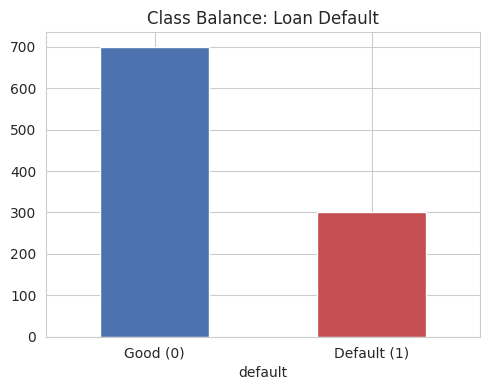

In [3]:
fig, ax = plt.subplots(figsize=(5,4))
df["default"].value_counts().sort_index().plot(kind="bar", ax=ax, color=["#4C72B0","#C44E52"])
ax.set_xticklabels(["Good (0)","Default (1)"], rotation=0)
ax.set_title("Class Balance: Loan Default")
plt.tight_layout()
plt.show()

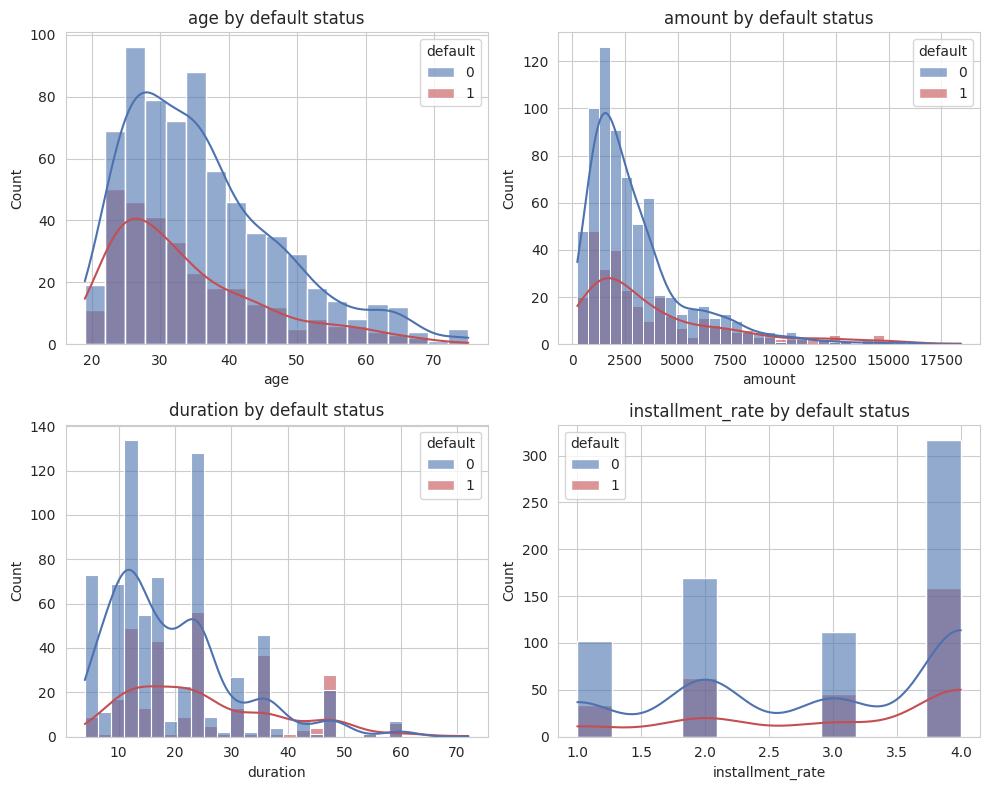

In [4]:
numeric_cols = ["age","amount","duration","installment_rate"]
fig, axes = plt.subplots(2,2, figsize=(10,8))
for ax, c in zip(axes.flat, numeric_cols):
    sns.histplot(data=df, x=c, hue="default", kde=True, ax=ax, palette=["#4C72B0","#C44E52"], alpha=0.6)
    ax.set_title(f"{c} by default status")
plt.tight_layout()
plt.show()

**Insight:** defaulters skew toward longer loan durations and larger amounts — intuitive, but worth confirming rather than assuming.

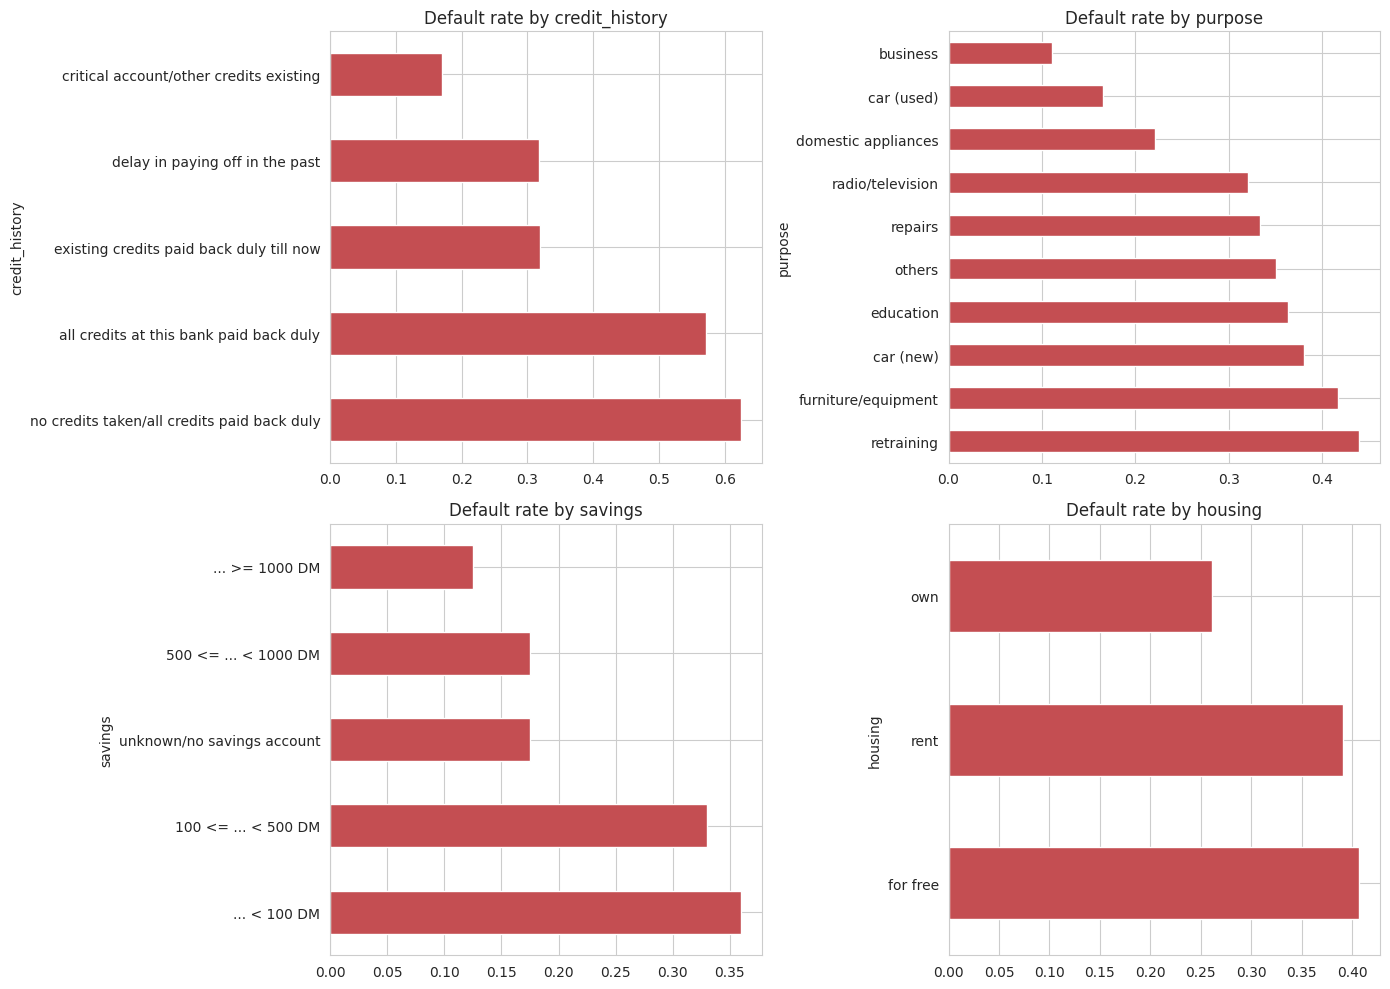

In [5]:
cat_cols = ["credit_history","purpose","savings","housing"]
fig, axes = plt.subplots(2,2, figsize=(14,10))
for ax, c in zip(axes.flat, cat_cols):
    df.groupby(c)["default"].mean().sort_values(ascending=False).plot(kind="barh", ax=ax, color="#C44E52")
    ax.set_title(f"Default rate by {c}")
plt.tight_layout()
plt.show()

**Counter-intuitive finding worth flagging honestly:** applicants with a "critical account / other credits existing" history and applicants with *no checking account at all* both show **lower** default rates than the "safer-looking" categories. This is a documented quirk of this specific dataset (likely a selection effect — long-standing customers with an established critical account elsewhere, or applicants who never needed a checking account tracked by this particular bank, may simply be a different population than the raw label suggests). I'm not hiding this because it makes the story cleaner — a real analyst has to report what the data says even when it's unintuitive, and flag it for a domain expert to sanity-check before it's fully trusted.

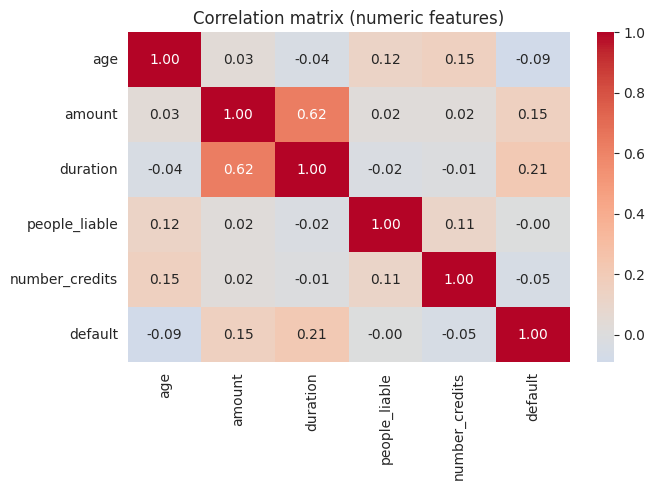

In [6]:
sensitive = ["age","amount","duration","people_liable","number_credits","default"]
fig, ax = plt.subplots(figsize=(7,5))
sns.heatmap(df[sensitive].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation matrix (numeric features)")
plt.tight_layout()
plt.show()

## 2. Feature Engineering

Beyond the raw fields, I engineered a few features that reflect how a credit officer would actually reason about risk:
- `monthly_burden` — loan amount relative to duration, scaled by installment rate (a proxy for repayment pressure)
- `amount_per_month` — raw amount / duration
- `risky_credit_history` — binary flag for past delays or critical accounts
- `no_checking_account` — binary flag (turned out to be one of the strongest signals, see SHAP section)
- `term_bucket` — binned loan duration

I also extracted two **sensitive attributes for the fairness analysis later** — `sex` (from the combined personal_status_sex field) and `age_group` (under 25 vs 25+, following the standard cutoff used in fairness literature on this dataset) — and deliberately **excluded them from the model's input features**, so the model can't use them directly to predict risk.

In [7]:
df["monthly_burden"] = (df["amount"] / df["duration"]) * (df["installment_rate"] / 4)
df["amount_per_month"] = df["amount"] / df["duration"]
df["risky_credit_history"] = df["credit_history"].isin(
    ["delay in paying off in the past","critical account/other credits existing"]).astype(int)
df["no_checking_account"] = (df["status"] == "no checking account").astype(int)
df["term_bucket"] = pd.cut(df["duration"], bins=[0,12,24,36,100],
                             labels=["short_<=12m","medium_13-24m","long_25-36m","very_long_>36m"])

df["sex"] = df["personal_status_sex"].apply(lambda x: "female" if "female" in x else "male")
df["age_group"] = df["age"].apply(lambda a: "under_25" if a < 25 else "25_and_over")

print("Default rate — no_checking_account flag:")
print(df.groupby("no_checking_account")["default"].mean())

Default rate — no_checking_account flag:
no_checking_account
0    0.419142
1    0.116751
Name: default, dtype: float64


## 3. Model Training & Comparison

I compared **3 model families** (Logistic Regression, Random Forest, XGBoost) x **2 imbalance-handling strategies** (class weighting vs SMOTE oversampling) — 6 models total, evaluated on a held-out 20% test set.

Why this matters for a lending use case: **recall on defaulters is usually worth more than raw accuracy**, because missing a real defaulter (false negative) costs the bank the full loan principal, while a false positive just costs a lost opportunity. So I'm optimizing for the precision/recall tradeoff, not accuracy alone.

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, RocCurveDisplay
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

target = "default"
drop_cols = ["credit_risk","default","personal_status_sex"]
sensitive_cols = ["sex","age_group"]
feature_cols = [c for c in df.columns if c not in drop_cols + sensitive_cols]

X = df[feature_cols]
y = df[target]
categorical = X.select_dtypes(include=["object","category"]).columns.tolist()
numeric = X.select_dtypes(include=["int64","float64"]).columns.tolist()

X_train, X_test, y_train, y_test, sens_train, sens_test = train_test_split(
    X, y, df[sensitive_cols], test_size=0.2, random_state=42, stratify=y)

preprocess = ColumnTransformer([
    ("num", StandardScaler(), numeric),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical),
])

/tmp/ipykernel_615/3990654466.py:19: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical = X.select_dtypes(include=["object","category"]).columns.tolist()


In [9]:
results = {}
fitted_models = {}

def evaluate(name, pipe):
    proba = pipe.predict_proba(X_test)[:,1]
    pred = pipe.predict(X_test)
    m = {"precision": round(precision_score(y_test,pred),3),
         "recall": round(recall_score(y_test,pred),3),
         "f1": round(f1_score(y_test,pred),3),
         "roc_auc": round(roc_auc_score(y_test,proba),3)}
    results[name] = m
    return m

models_balanced = {
    "LogisticRegression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42),
    "XGBoost": XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                              scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
                              eval_metric="logloss", random_state=42),
}
for name, model in models_balanced.items():
    pipe = Pipeline([("prep", preprocess), ("model", model)])
    pipe.fit(X_train, y_train)
    fitted_models[f"{name}_class_weighted"] = pipe
    evaluate(f"{name}_class_weighted", pipe)

models_plain = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=300, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05, eval_metric="logloss", random_state=42),
}
for name, model in models_plain.items():
    pipe = ImbPipeline([("prep", preprocess), ("smote", SMOTE(random_state=42)), ("model", model)])
    pipe.fit(X_train, y_train)
    fitted_models[f"{name}_SMOTE"] = pipe
    evaluate(f"{name}_SMOTE", pipe)

results_df = pd.DataFrame(results).T.sort_values("roc_auc", ascending=False)
results_df

,precision,recall,f1,roc_auc
LogisticRegression_class_weighted,0.565,0.800,0.662,0.803
XGBoost_SMOTE,0.643,0.600,0.621,0.799
LogisticRegression_SMOTE,0.547,0.783,0.644,0.793
RandomForest_class_weighted,0.667,0.400,0.500,0.788
RandomForest_SMOTE,0.652,0.500,0.566,0.787
XGBoost_class_weighted,0.578,0.617,0.597,0.783


**Reading the table:** the class-weighted Logistic Regression came out on top by ROC-AUC (0.803) and has the best recall (0.80) of any model — meaning it catches 80% of actual defaulters. But its precision (0.565) is fairly low: roughly 44% of applicants it flags as high-risk are false alarms.

That's a real, defensible business tradeoff, not a flaw to hide: for this use case, missing a defaulter is more expensive than a false alarm, so I'm prioritizing recall — but a production deployment would need a human review step for flagged applicants precisely because precision is this low, rather than auto-rejecting on the model's word alone.

XGBoost with SMOTE is the strongest tree-based alternative (ROC-AUC 0.799, better precision at 0.643) — a reasonable choice if the business instead wanted to minimize false alarms and could tolerate missing more defaulters.

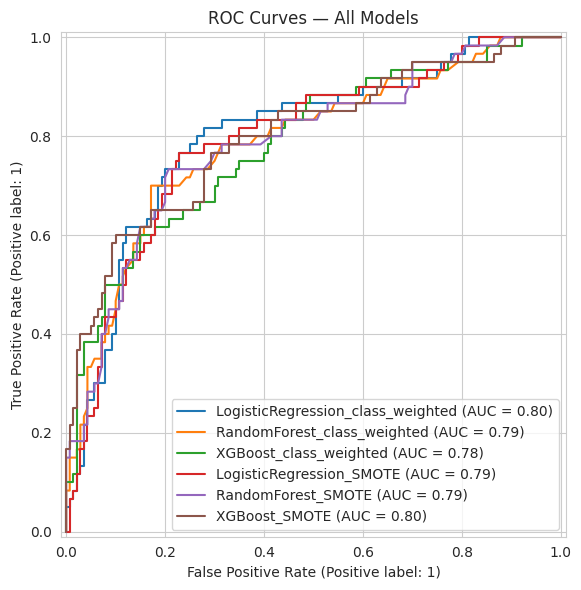

In [10]:
fig, ax = plt.subplots(figsize=(7,6))
for name, pipe in fitted_models.items():
    RocCurveDisplay.from_estimator(pipe, X_test, y_test, ax=ax, name=name)
ax.set_title("ROC Curves — All Models")
plt.tight_layout()
plt.show()

In [11]:
best_name = results_df.index[0]
best_pipe = fitted_models[best_name]
print("Best model:", best_name)
print(confusion_matrix(y_test, best_pipe.predict(X_test)))

Best model: LogisticRegression_class_weighted
[[103  37]
 [ 12  48]]


## 4. Explainability (SHAP)

The best model is Logistic Regression, which is already interpretable via coefficients — but SHAP gives per-prediction, magnitude-ranked explanations that are far easier to communicate to a non-technical stakeholder (or to a regulator, which matters a lot in lending).

Background dataset has 200 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=200 when initializing the masker.


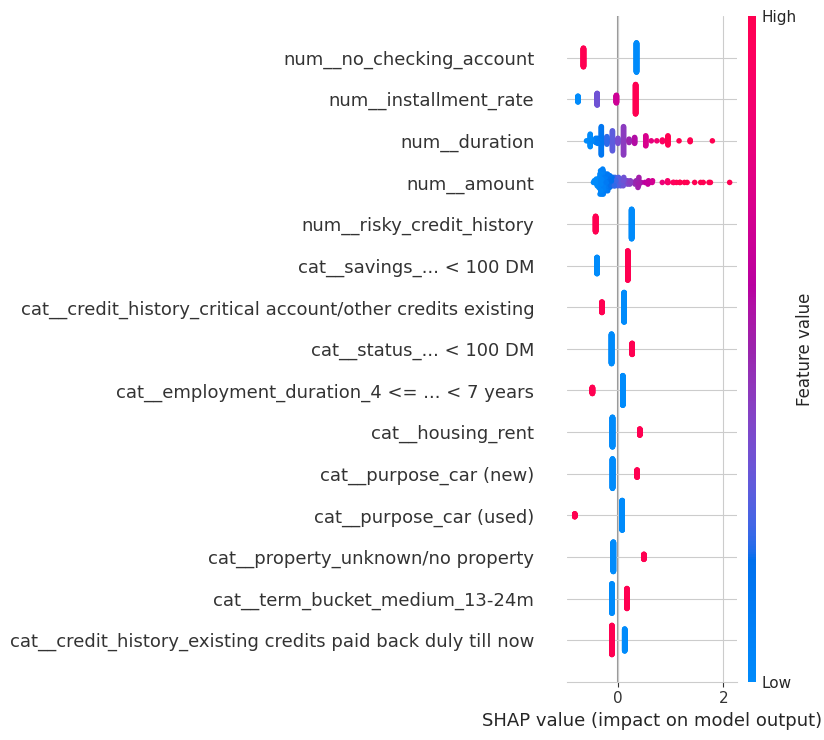

In [12]:
import shap

prep = best_pipe.named_steps["prep"]
model = best_pipe.named_steps["model"]

X_test_t = prep.transform(X_test)
if hasattr(X_test_t, "toarray"):
    X_test_t = X_test_t.toarray()
feat_names = prep.get_feature_names_out()
X_test_df = pd.DataFrame(X_test_t, columns=feat_names)

explainer = shap.LinearExplainer(model, X_test_df)
shap_values = explainer(X_test_df)

shap.summary_plot(shap_values, X_test_df, max_display=15)

**Top drivers of predicted default risk**, ranked by mean |SHAP value|:
1. `no_checking_account` — strongest signal overall (and counter-intuitively, its *absence* of a tracked checking account lowers predicted risk — same quirk flagged in the EDA section)
2. `installment_rate` — higher repayment burden relative to income → higher risk
3. `duration` — longer loans → higher risk
4. `amount` — larger loans → higher risk
5. `risky_credit_history` — past delays/critical accounts

This mostly matches domain intuition (duration, amount, repayment burden), which is reassuring — the model isn't relying on anything obviously spurious. The `no_checking_account` result is the one finding I'd want to validate with a domain expert before trusting it in production, exactly because it cuts against intuition.

## 5. Fairness Analysis (Fairlearn)

This is the part a pure accuracy-focused project skips, and it's the part that matters most in a regulated domain like lending. I evaluated the deployed model's predictions across two sensitive attributes it was **never given as an input feature**: sex and age group (under 25 vs 25+, a legally relevant cutoff in credit fairness literature).

In [13]:
from fairlearn.metrics import (MetricFrame, selection_rate, false_positive_rate, false_negative_rate,
                                demographic_parity_difference, equalized_odds_difference)

y_pred = best_pipe.predict(X_test)

for col in ["sex","age_group"]:
    sf = sens_test[col]
    mf = MetricFrame(
        metrics={"selection_rate": selection_rate, "recall": recall_score, "precision": precision_score,
                 "false_positive_rate": false_positive_rate, "false_negative_rate": false_negative_rate},
        y_true=y_test, y_pred=y_pred, sensitive_features=sf)
    print(f"--- {col} ---")
    display(mf.by_group)
    print(f"Demographic parity difference: {demographic_parity_difference(y_test, y_pred, sensitive_features=sf):.3f}")
    print(f"Equalized odds difference: {equalized_odds_difference(y_test, y_pred, sensitive_features=sf):.3f}\n")

--- sex ---


,selection_rate,recall,precision,false_positive_rate,false_negative_rate
sex,,,,,
female,0.42623,0.8,0.615385,0.243902,0.2
male,0.42446,0.8,0.542373,0.272727,0.2


Demographic parity difference: 0.002
Equalized odds difference: 0.029

--- age_group ---


,selection_rate,recall,precision,false_positive_rate,false_negative_rate
age_group,,,,,
25_and_over,0.397516,0.804878,0.515625,0.258333,0.195122
under_25,0.538462,0.789474,0.714286,0.300000,0.210526


Demographic parity difference: 0.141
Equalized odds difference: 0.042



**By sex:** the model is essentially fair. Selection rate (42.6% female vs 42.4% male) and recall (0.80 for both) are nearly identical. Demographic parity difference is just 0.002 — negligible.

**By age group:** a real disparity shows up. Applicants under 25 are flagged as high-risk **53.8% of the time**, versus **39.8%** for applicants 25 and older — a demographic parity difference of **0.141**. Recall is similar across both groups (~0.79–0.80, so the model isn't systematically *missing* more young defaulters), but young applicants are simply flagged far more often overall, and their false positive rate is also higher (0.30 vs 0.26).

**What I'd do about this:** age itself isn't in the model, so this disparity is coming through correlated features — most plausibly `duration`/`amount` patterns and thinner credit history, which genuinely correlate with age in this population. That doesn't make it acceptable to ship as-is. In a real deployment I would: (1) flag this to compliance/legal before launch, since disparate impact on a protected age group can be a regulatory issue even without explicit age as a feature, (2) test a fairness-constrained version of the model (Fairlearn supports this directly via `ExponentiatedGradient`) and measure the accuracy-fairness tradeoff, and (3) recommend human review specifically for borderline young applicants rather than auto-decisioning.

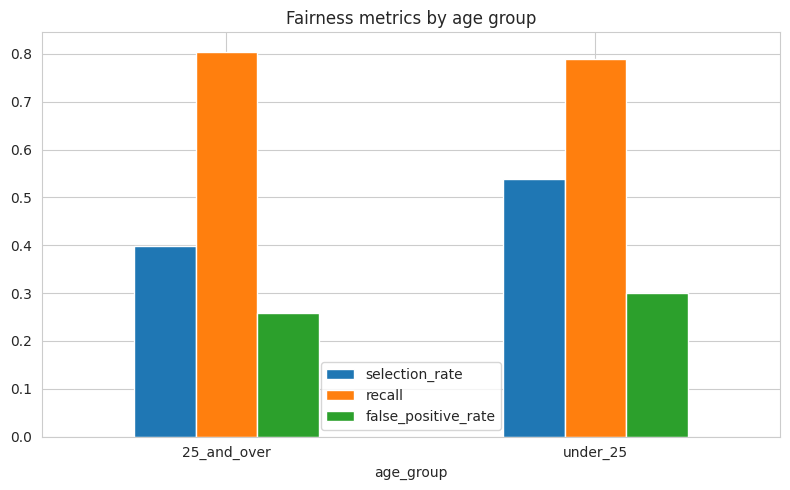

In [14]:
fig, ax = plt.subplots(figsize=(8,5))
sf = sens_test["age_group"]
mf = MetricFrame(metrics={"selection_rate": selection_rate, "recall": recall_score, "false_positive_rate": false_positive_rate},
                  y_true=y_test, y_pred=y_pred, sensitive_features=sf)
mf.by_group.plot(kind="bar", ax=ax)
ax.set_title("Fairness metrics by age group")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 6. Summary

| Question | Answer |
|---|---|
| Best model | Logistic Regression, class-weighted (ROC-AUC 0.803, recall 0.80) |
| Key tradeoff | High recall on defaulters, but precision is only 0.565 — needs human review layer in production |
| Top risk drivers | Checking account status, installment burden, loan duration, loan amount, credit history |
| Fair by sex? | Yes — demographic parity difference of 0.002 |
| Fair by age? | No — under-25 applicants flagged as high-risk ~14 points more often, needs mitigation before deployment |
| What I'd do next | Try `ExponentiatedGradient` fairness-constrained training, add a human-review threshold band, validate the `no_checking_account` finding with a domain expert |
